# HW 2 Coding Qs

In [208]:
import pandas as pd
from plotnine import  * 
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

In [209]:
# Read CSV file
hospital_infection = pd.read_csv("../data/hospital_infection.csv")

# Display the first few rows
hospital_infection.head()

,ID,Stay,Age,InfctRsk,Culture,Xray,Beds,MedSchool,Region,Census,Nurses,Facilities
0,5,11.20,56.5,5.7,34.5,88.9,180,2,1,134,151,40.0
1,10,8.84,56.3,6.3,29.6,82.6,85,2,1,59,66,40.0
2,11,11.07,53.2,4.9,28.5,122.0,768,1,1,591,656,80.0
3,13,12.78,56.8,7.7,46.0,116.9,322,1,1,252,349,57.1
4,18,11.62,53.9,6.4,25.5,99.2,133,2,1,113,101,37.1


In [210]:
# Check if missing values
complete_index = hospital_infection.notnull().all(axis=1) 
print(complete_index.describe()) 

count       58
unique       1
top       True
freq        58
dtype: object


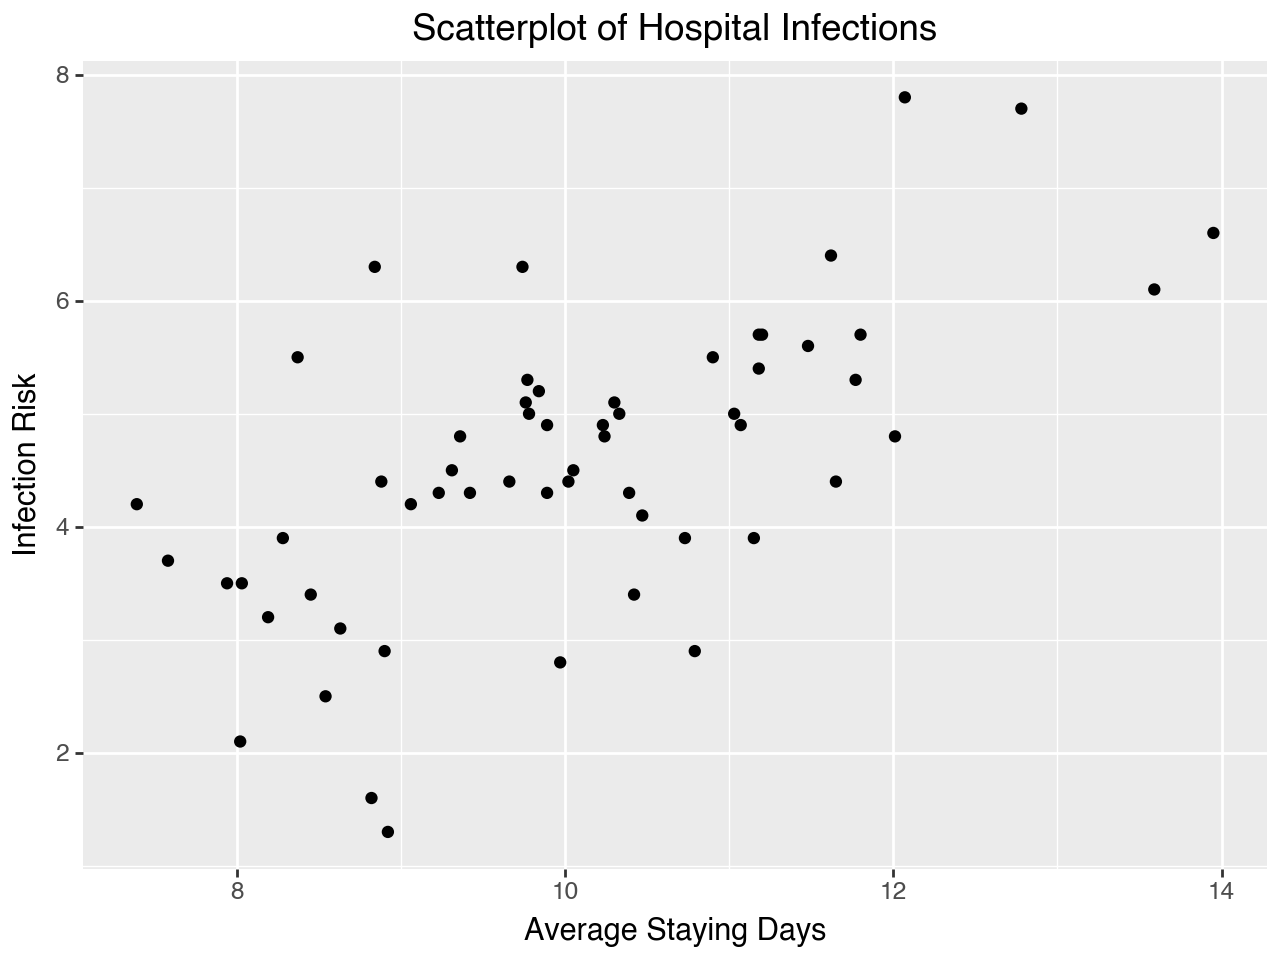

In [211]:
# Initial scatterplot
ggplot(hospital_infection, aes(x='Stay', y='InfctRsk')) + \
    geom_point() + \
    labs(title='Scatterplot of Hospital Infections', x='Average Staying Days', y='Infection Risk') 

## 1a. 
The relationship I can observe is that there seems to be a linearly positive relationship between average staying days and the infection risk. 

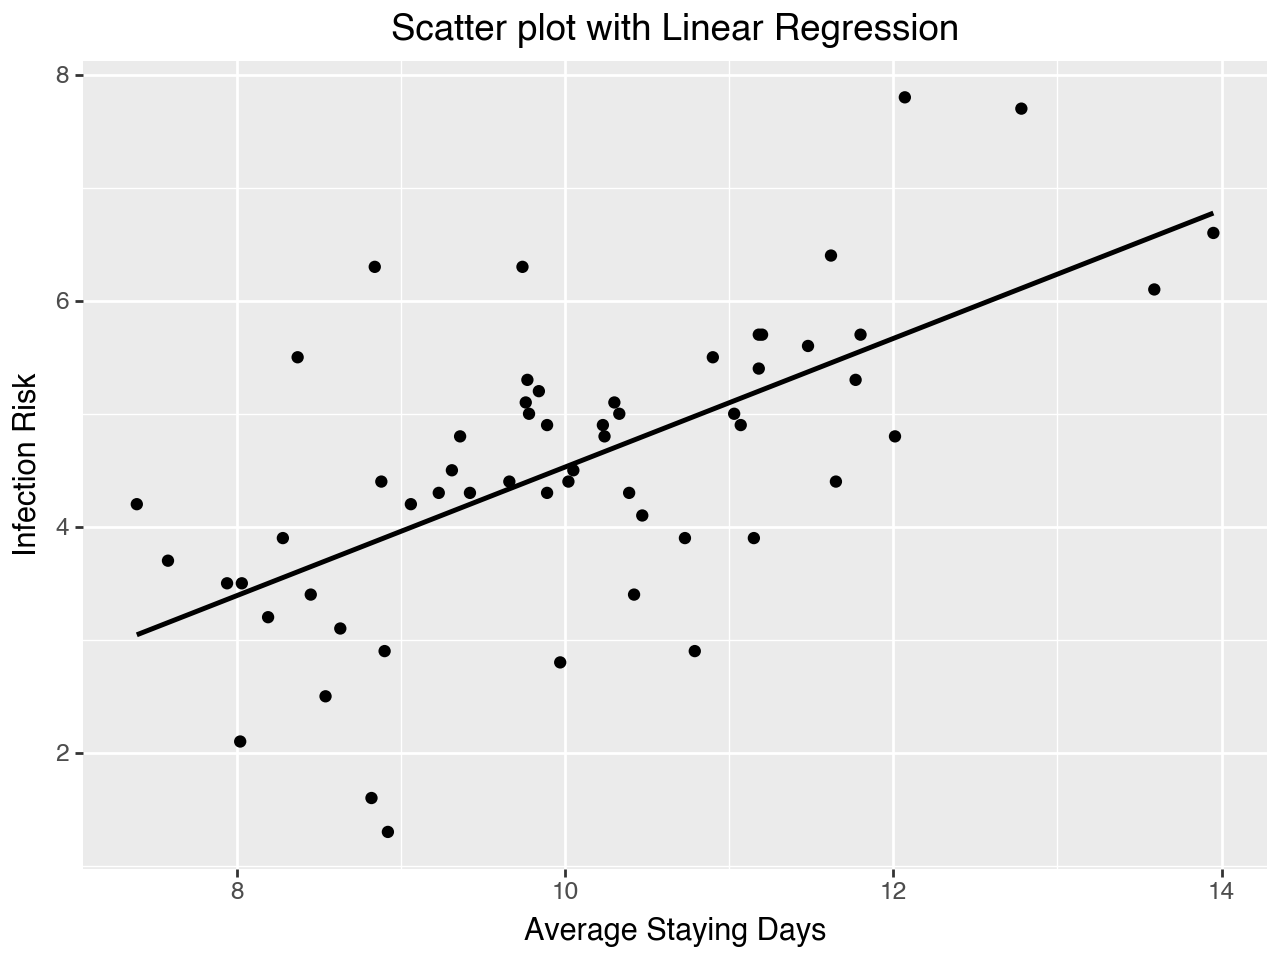

In [212]:
# Scatter plot with linear regression line
regression_plot = (
    ggplot(hospital_infection, aes(x='Stay', y='InfctRsk')) +
    geom_point() +
    geom_smooth(method='lm', formula='y ~ x', se=False) +
    labs(title='Scatter plot with Linear Regression', x='Average Staying Days', y='Infection Risk')
)
regression_plot

In [213]:
# Fit linear model
X = hospital_infection[['Stay']]
y = hospital_infection[['InfctRsk']]
model = LinearRegression().fit(X, y)

In [214]:
model.intercept_, model.coef_

(array([-1.15981903]), array([[0.56886646]]))

In [215]:
# Linear model summary
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope: {slope}, Intercept: {intercept}")

Slope: [0.56886646], Intercept: [-1.15981903]


## 1b.
The equation of the fitted regression line:

$\hat{y}_i = -1.1598 + 0.5689 x_i$

In [216]:
X = sm.add_constant(X)  # add intercept
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               InfctRsk   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     36.50
Date:                Sat, 06 Sep 2025   Prob (F-statistic):           1.30e-07
Time:                        17:42:12   Log-Likelihood:                -82.684
No. Observations:                  58   AIC:                             169.4
Df Residuals:                      56   BIC:                             173.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1598      0.956     -1.213      0.230      -3.075       0.755
Stay           0.5689      0.094      6.041      0.000       0.380       0.757
==============================================================================
Omnibus:                        1.579   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.454   Jarque-Bera (JB):                0.839
Skew:                          -0.170   Prob(JB):                        0.657
Kurtosis:                       3.481   Cond. No.                         72.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 1c. 

For Stay, the t-statistic is 6.041 and p-value is p < 0.001. This means that we can reject the null hypothesis that the slope is zero since there is pretty much a zero probability that we would get a result that extreme. This suggests there is a linear relationship between Stay and Infection Risk. For each extra unit of average staying days, infection risk increases on average by 0.57 units.

In [217]:
model.conf_int(alpha=0.05)

,0,1
const,-3.074509,0.754871
Stay,0.380233,0.757499


In [218]:
# CI calculations
n = len(X)
x_values = X['Stay'].values
y_values = y['InfctRsk'].values
b1 = 0.5689
y_pred = model.predict(X)
residuals = y_values - y_pred

# Mean Squared Error 
mse = np.sum(residuals**2) / (n - 2)

# Sum of Squares
x_mean = np.mean(x_values)
ssx = np.sum((x_values - x_mean)**2)

# Standard error 
se = np.sqrt(mse / ssx)

# T statistic
t_statistic = 2.0

# 95% Confidence Interval for β₁
ci_lower = b1 - t_statistic * se
ci_upper = b1 + t_statistic * se
print(ci_lower)
print(ci_upper)

0.3805721345907609
0.757227865409239


## 1d. 

Yes, the calculations match with the result of the summary output. 

In [219]:
import statsmodels.formula.api as smf

model = smf.ols('InfctRsk ~ Stay',hospital_infection).fit() #formula: 'y~x' or 'y~x1+x2+x3..'
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               InfctRsk   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     36.50
Date:                Sat, 06 Sep 2025   Prob (F-statistic):           1.30e-07
Time:                        17:42:12   Log-Likelihood:                -82.684
No. Observations:                  58   AIC:                             169.4
Df Residuals:                      56   BIC:                             173.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1598      0.956     -1.213      0.230      -3.075       0.755
Stay           0.5689      0.094      6.041      0.000       0.380       0.757
==============================================================================
Omnibus:                        1.579   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.454   Jarque-Bera (JB):                0.839
Skew:                          -0.170   Prob(JB):                        0.657
Kurtosis:                       3.481   Cond. No.                         72.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [220]:
# ANOVA
aov_table = sm.stats.anova_lm(model, typ=1)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Stay,1.0,38.305918,38.305918,36.496522,1.302453e-07
Residual,56.0,58.776324,1.049577,NaN,NaN


# 1e. 
The F-test statistic is 36.496522 and the p-value is p < 0.001. This suggests that we can reject the null hypothesis that the slope is 0 with full confidence, and average stay days is a significant predictor of infection risk. 

In [221]:
t_value = model.tvalues[1] 
print(t_value ** 2)

36.496521925547434


/var/folders/xj/rb62l69s6p1d_vb461s2vgcm0000gn/T/ipykernel_34455/2351354902.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


# 1f. 

Squaring the T-statistic gives us the same value as the F-statistic. The p-values are also both less than 0.0001 so they are approximately the same.

# 1g.

From the summary, the value of R^2 is 0.395. It suggests that 36.5% of the variance in infection risk is predicted by average stay days. The other 63.5% is unexplained by the model. X is a good predictor but could be better. 

In [222]:
# Predict infection risk with Stay = 32
b0 = -1.1598
b1 = 0.5689
x = 32

y_prediction = b1 * x + b0
y_prediction

17.044999999999998

# 1h. 

The predicted infection risk for an average stay length of 32 days is 17.045

In [223]:
# 95% CI for the mean infection risk when the average stay is 32 days

X_32 = sm.add_constant(X)
model_sm = sm.OLS(y, X_32).fit()

x_new = np.array([[1, x]]) 
pred_summary = model_sm.get_prediction(x_new).summary_frame(alpha=0.05)
ci_lower = pred_summary['mean_ci_lower']
ci_upper = pred_summary['mean_ci_upper']
print(f"{ci_lower}, {ci_upper}")

0    12.894523
Name: mean_ci_lower, dtype: float64, 0    21.193292
Name: mean_ci_upper, dtype: float64


In [224]:
# 95% prediction interval
pi_lower = pred_summary['obs_ci_lower']
pi_upper = pred_summary['obs_ci_upper']
print(f"{pi_lower}, {pi_upper}")

0    12.414726
Name: obs_ci_lower, dtype: float64, 0    21.673089
Name: obs_ci_upper, dtype: float64


# 3.
The 95% confidence interval is (12.894523, 21.193292) and 95% prediction interval is (12.414726, 21.673089)